In [13]:
import random
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [14]:
names = open("names.txt").read().splitlines()
names[:3]

['emma', 'olivia', 'ava']

In [15]:
chars = sorted(list(set(''.join(names))))
chars[:3]

['a', 'b', 'c']

In [16]:
c_to_idx = {}
idx_to_c = {}

for idx, c in enumerate(chars):
    c_to_idx[c] = idx+1
    idx_to_c[idx+1] = c

c_to_idx['.'] = 0
idx_to_c[0] = '.'

print(c_to_idx)
print(idx_to_c)

{'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26, '.': 0}
{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [17]:
block_size = 3

x = []
y = []

for name in names[:6]:
    context = [0] * block_size
    for c in name:
        x.append(context.copy())
        y.append(c_to_idx[c])

        # changing context for next
        context[0] = context[1]
        context[1] = context[2]
        context[2] = c_to_idx[c]

X = torch.tensor(x)
Y = torch.tensor(y)

print(x)
print(y)

for i in range(len(y)):
    # print(names[i])
    num1 = x[i][0]
    num2 = x[i][1]
    num3 = x[i][2]
    print(f"{idx_to_c[num1]}{idx_to_c[num2]}{idx_to_c[num3]} -------> {idx_to_c[y[i]]}")

[[0, 0, 0], [0, 0, 5], [0, 5, 13], [5, 13, 13], [0, 0, 0], [0, 0, 15], [0, 15, 12], [15, 12, 9], [12, 9, 22], [9, 22, 9], [0, 0, 0], [0, 0, 1], [0, 1, 22], [0, 0, 0], [0, 0, 9], [0, 9, 19], [9, 19, 1], [19, 1, 2], [1, 2, 5], [2, 5, 12], [5, 12, 12], [0, 0, 0], [0, 0, 19], [0, 19, 15], [19, 15, 16], [15, 16, 8], [16, 8, 9], [0, 0, 0], [0, 0, 3], [0, 3, 8], [3, 8, 1], [8, 1, 18], [1, 18, 12], [18, 12, 15], [12, 15, 20], [15, 20, 20]]
[5, 13, 13, 1, 15, 12, 9, 22, 9, 1, 1, 22, 1, 9, 19, 1, 2, 5, 12, 12, 1, 19, 15, 16, 8, 9, 1, 3, 8, 1, 18, 12, 15, 20, 20, 5]
... -------> e
..e -------> m
.em -------> m
emm -------> a
... -------> o
..o -------> l
.ol -------> i
oli -------> v
liv -------> i
ivi -------> a
... -------> a
..a -------> v
.av -------> a
... -------> i
..i -------> s
.is -------> a
isa -------> b
sab -------> e
abe -------> l
bel -------> l
ell -------> a
... -------> s
..s -------> o
.so -------> p
sop -------> h
oph -------> i
phi -------> a
... -------> c
..c -------> h
.ch

In [18]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([36, 3]), torch.int64, torch.Size([36]), torch.int64)

In [19]:
C = torch.randn((27, 2))
C

tensor([[-1.1842,  1.7339],
        [ 0.5655,  0.4680],
        [-0.2873, -0.2391],
        [ 1.2798,  0.9945],
        [ 0.3396,  0.9022],
        [ 1.3293,  1.2796],
        [ 0.5399,  0.5600],
        [-1.3612, -1.5461],
        [ 0.9699, -0.1730],
        [-0.7447, -1.2039],
        [ 1.6012, -0.9280],
        [ 0.4647,  0.3367],
        [-1.0541,  0.8905],
        [-1.6356, -0.9425],
        [ 0.9256, -1.0594],
        [-0.8164, -0.8250],
        [-1.3052, -0.6136],
        [-0.0235, -1.2068],
        [ 0.2611,  1.9946],
        [-1.7151, -0.2276],
        [-0.7037,  0.2754],
        [ 1.6881,  0.1752],
        [-0.7497, -0.7002],
        [ 1.3033,  1.8167],
        [-0.0215,  0.5132],
        [ 1.4013, -0.2715],
        [-0.8266,  0.1689]])

In [20]:
emb = C[X]
print(emb.shape)
emb

torch.Size([36, 3, 2])


tensor([[[-1.1842,  1.7339],
         [-1.1842,  1.7339],
         [-1.1842,  1.7339]],

        [[-1.1842,  1.7339],
         [-1.1842,  1.7339],
         [ 1.3293,  1.2796]],

        [[-1.1842,  1.7339],
         [ 1.3293,  1.2796],
         [-1.6356, -0.9425]],

        [[ 1.3293,  1.2796],
         [-1.6356, -0.9425],
         [-1.6356, -0.9425]],

        [[-1.1842,  1.7339],
         [-1.1842,  1.7339],
         [-1.1842,  1.7339]],

        [[-1.1842,  1.7339],
         [-1.1842,  1.7339],
         [-0.8164, -0.8250]],

        [[-1.1842,  1.7339],
         [-0.8164, -0.8250],
         [-1.0541,  0.8905]],

        [[-0.8164, -0.8250],
         [-1.0541,  0.8905],
         [-0.7447, -1.2039]],

        [[-1.0541,  0.8905],
         [-0.7447, -1.2039],
         [-0.7497, -0.7002]],

        [[-0.7447, -1.2039],
         [-0.7497, -0.7002],
         [-0.7447, -1.2039]],

        [[-1.1842,  1.7339],
         [-1.1842,  1.7339],
         [-1.1842,  1.7339]],

        [[-1.1842,  1

In [21]:
emb.view(-1, 6) # this will be our input matrix. by using -1 torch infers the size by itself
# 6 / 3 is the size of each vector that represents a character
# note: view is autorgrad aware and hence gradient descent happens perfectly when we use view

tensor([[-1.1842,  1.7339, -1.1842,  1.7339, -1.1842,  1.7339],
        [-1.1842,  1.7339, -1.1842,  1.7339,  1.3293,  1.2796],
        [-1.1842,  1.7339,  1.3293,  1.2796, -1.6356, -0.9425],
        [ 1.3293,  1.2796, -1.6356, -0.9425, -1.6356, -0.9425],
        [-1.1842,  1.7339, -1.1842,  1.7339, -1.1842,  1.7339],
        [-1.1842,  1.7339, -1.1842,  1.7339, -0.8164, -0.8250],
        [-1.1842,  1.7339, -0.8164, -0.8250, -1.0541,  0.8905],
        [-0.8164, -0.8250, -1.0541,  0.8905, -0.7447, -1.2039],
        [-1.0541,  0.8905, -0.7447, -1.2039, -0.7497, -0.7002],
        [-0.7447, -1.2039, -0.7497, -0.7002, -0.7447, -1.2039],
        [-1.1842,  1.7339, -1.1842,  1.7339, -1.1842,  1.7339],
        [-1.1842,  1.7339, -1.1842,  1.7339,  0.5655,  0.4680],
        [-1.1842,  1.7339,  0.5655,  0.4680, -0.7497, -0.7002],
        [-1.1842,  1.7339, -1.1842,  1.7339, -1.1842,  1.7339],
        [-1.1842,  1.7339, -1.1842,  1.7339, -0.7447, -1.2039],
        [-1.1842,  1.7339, -0.7447, -1.2

# Start here

In [149]:
# ok now let's create the full neural network

# define the hyperparametes
EMB_SIZE = 50
HIDDEN_LAYER_SIZE = 300
N_OUTPUTS = 27
EPOCHS = 400000
BLOCK_SIZE = 3

In [150]:
names = open("names.txt").read().splitlines()

c_to_idx = {}
idx_to_c = {}

chars = sorted(list(set(''.join(names))))

for idx, c in enumerate(chars):
    c_to_idx[c] = idx+1
    idx_to_c[idx+1] = c

c_to_idx['.'] = 0
idx_to_c[0] = '.'


def build_dataset(names):

    x = []
    y = []

    for name in names:
        context = [0] * BLOCK_SIZE
        for c in name + '.':
            x.append(context.copy())
            y.append(c_to_idx[c])

            # changing context for next
            context[0] = context[1]
            context[1] = context[2]
            context[2] = c_to_idx[c]

    X = torch.tensor(x)
    Y = torch.tensor(y)

    return X, Y

random.shuffle(names)

n1 = int(0.8*len(names))
n2 = int(0.9*len(names))

Xtr, Ytr = build_dataset(names[:n1])
Xdev, Ydev = build_dataset(names[n1:n2])
Xtest, Ytest = build_dataset(names[n2:])

print(Xtr.shape, Xdev.shape, Xtest.shape)
print(Ytr.shape, Ydev.shape, Ytest.shape)

torch.Size([182363, 3]) torch.Size([22895, 3]) torch.Size([22888, 3])
torch.Size([182363]) torch.Size([22895]) torch.Size([22888])


In [151]:
print(f'train: {n1}, val: {n2 - n1}, test: {len(names) - n2}')

train: 25626, val: 3203, test: 3204


In [152]:
C = torch.randn((27, EMB_SIZE))
w1 = torch.randn((EMB_SIZE * 3, HIDDEN_LAYER_SIZE)) # (6, 100)
b1 = torch.randn(HIDDEN_LAYER_SIZE) # (100)
w2 = torch.randn((HIDDEN_LAYER_SIZE, N_OUTPUTS)) # (100, 27) most of the computation is here
b2 = torch.rand(N_OUTPUTS) # (27)

parameters = [C, w1, b1, w2, b2]

In [153]:
print(f'number of params: {sum(p.nelement() for p in parameters)}')

number of params: 54777


In [154]:
for p in parameters:
    p.requires_grad = True

In [155]:
lossi = []
stepi = []
lri = []

lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

loss = torch.tensor(0.0)

for i in range(EPOCHS):

    # minibatch
    batch = torch.randint(0, Xtr.shape[0], (64,))
    # print(batch)

    # forward pass
    emb = C[Xtr[batch]]
    h = torch.tanh(emb.view(-1, EMB_SIZE * 3) @ w1 + b1) # (36, 6) * (6, 100) -> (36, 100)
    logits = h @ w2 + b2 # (36, 100) * (100, 27) -> (36, 27)
    loss = F.cross_entropy(logits, Ytr[batch])
    # print(loss.item())

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 200000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # print loss
    if i % 1000 == 0:
        print(f'epoch {i}: {loss.item()}, {lr}')

    # track stats
    lossi.append(loss.item())
    stepi.append(i)

print(loss.item())

epoch 0: 31.587902069091797, 0.1
epoch 1000: 5.098496437072754, 0.1
epoch 2000: 4.091747283935547, 0.1
epoch 3000: 3.3741753101348877, 0.1
epoch 4000: 3.566352605819702, 0.1
epoch 5000: 2.854491710662842, 0.1
epoch 6000: 2.639667510986328, 0.1
epoch 7000: 2.783238649368286, 0.1
epoch 8000: 2.8334848880767822, 0.1
epoch 9000: 3.0211904048919678, 0.1
epoch 10000: 2.19923996925354, 0.1
epoch 11000: 3.121351480484009, 0.1
epoch 12000: 2.7181878089904785, 0.1
epoch 13000: 2.300666093826294, 0.1
epoch 14000: 2.776667356491089, 0.1
epoch 15000: 2.630592107772827, 0.1
epoch 16000: 2.1143789291381836, 0.1
epoch 17000: 2.168588399887085, 0.1
epoch 18000: 2.238497734069824, 0.1
epoch 19000: 2.3473763465881348, 0.1
epoch 20000: 2.4945061206817627, 0.1
epoch 21000: 2.3670737743377686, 0.1
epoch 22000: 2.673196315765381, 0.1
epoch 23000: 2.064897298812866, 0.1
epoch 24000: 2.1336631774902344, 0.1
epoch 25000: 1.9552865028381348, 0.1
epoch 26000: 1.9253019094467163, 0.1
epoch 27000: 2.540761709213257

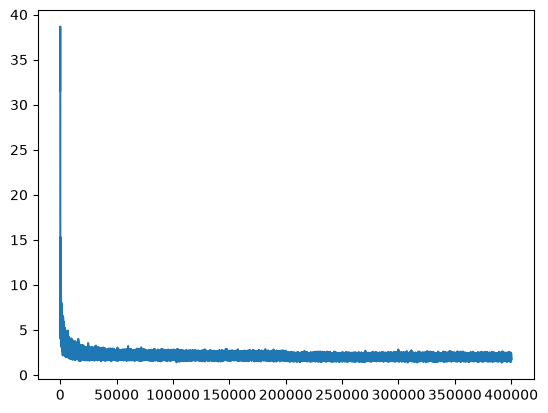

In [158]:
plt.plot(stepi, lossi)

In [156]:
 # loss on val set 
emb = C[Xdev]
h = torch.tanh(emb.view(-1, EMB_SIZE * 3) @ w1 + b1) # (36, 6) * (6, 100) -> (36, 100)
logits = h @ w2 + b2 # (36, 100) * (100, 27) -> (36, 27)
loss = F.cross_entropy(logits, Ydev)
print(loss.item())

2.1475613117218018


In [157]:
# loss on test set 
emb = C[Xtest]
h = torch.tanh(emb.view(-1, EMB_SIZE * 3) @ w1 + b1) # (36, 6) * (6, 100) -> (36, 100)
logits = h @ w2 + b2 # (36, 100) * (100, 27) -> (36, 27)
loss = F.cross_entropy(logits, Ytest)
print(loss.item())

2.149712085723877


In [186]:
# sample from the model

g = torch.Generator().manual_seed(2147483647)

for _ in range(20):
    out = []
    context = [0] * BLOCK_SIZE

    while True:
        emb = C[torch.tensor(context)]
        h = torch.tanh(emb.view(1, -1) @ w1 + b1)
        logits = h @ w2 + b2
        probs = F.softmax(logits, dim=1)
        
        idx = torch.multinomial(probs, 1, generator=g).item()
        
        out.append(idx_to_c[idx]) 

        context = context[1:] + [idx]
        
        if idx_to_c[idx] == '.':
            break
    
    print(''.join(out))

junide.
jakarie.
parshy.
adin.
kai.
rito.
sabrayel.
kalania.
zamilenaas.
deyairraimel.
sejy.
evy.
artez.
avelleryn.
demmere.
nastinor.
and.
core.
yae.
anna.


In [160]:
# sample from the model
g = torch.Generator().manual_seed(2147483647)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ w1 + b1)
      logits = h @ w2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(idx_to_c[i] for i in out))


junide.
jakarie.
parshy.
adin.
kai.
rito.
sabrayel.
kalania.
zamilenaas.
deyairraimel.
sejy.
evy.
artez.
avelleryn.
demmere.
nastinor.
and.
core.
yae.
anna.
